# Notebook 03 — Confidence Intervals & Credible Intervals
## Repository: `moby/moby` (Docker Engine)

**Member C:** [Nama C] — Inference Analyst  
**Modul:** `src/inference.py`  
**Referensi:** Tsun, *Probability & Statistics with Applications to Computing*, 2020.

---

### Research Questions yang Dijawab

| # | Research Question | Teknik | Input dari |
|---|-------------------|--------|-----------|
| **RQ1 (lanjutan)** | Seberapa tidak pasti estimasi merge rate θ̂? | CI 95% & 99% Frequentist + Credible Interval Bayesian | Notebook 02 (Member B) |
| **RQ2 (lanjutan)** | Seberapa tidak pasti λ̂ baseline bug/minggu? | CI Poisson 95% | Notebook 02 (Member B) |

**Input:**  
- Nilai `K`, `N`, `ALPHA_POST`, `BETA_POST` dari Notebook 02  
- `data/clean/weekly_bugs.csv` (dari Member A)

**Output:** Tabel & visualisasi interval yang diteruskan ke Member D

## Disclosure Penggunaan AI

*(Isi jujur sesuai kondisi aktual)*

| Aspek | Detail |
|-------|--------|
| Tool AI yang digunakan | [Contoh: Claude, ChatGPT, GitHub Copilot] |
| % kode yang dibantu AI | [Contoh: ~40%] |
| Interpretasi statistik dibantu AI? | No — seluruh interpretasi ditulis sendiri |
| Prompt utama | [Ringkasan 1–2 kalimat] |
| Koreksi yang dilakukan | [Jelaskan perubahan dari output AI] |

> **Catatan penting:** Wording interpretasi CI frequentist dan credible interval  
> **WAJIB** ditulis sendiri — bukan copy-paste dari AI.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
import sys

# Sesuaikan path jika struktur folder berbeda
sys.path.append("../src")
from inference import ci_bernoulli, ci_poisson, credible_interval, confidence_interval

# =============================================================================
#  NILAI DARI MEMBER B (Notebook 02)
#  UPDATE nilai K dan N setelah Member B selesai menjalankan Notebook 02!
# =============================================================================
K          = 743          # jumlah PR yang di-merge (sukses)
N          = 884          # total PR closed yang dianalisis
M          = N - K        # PR closed tanpa merge = 141
THETA_HAT  = K / N        # theta_hat MLE = 0.840498...

ALPHA_POST = K + 1        # alpha Beta posterior = 744  <-- WAJIB +1
BETA_POST  = M + 1        # beta  Beta posterior = 142  <-- WAJIB +1

# Load data weekly bugs dari Member A
try:
    weekly      = pd.read_csv("../data/clean/weekly_bugs.csv")
    bugs_before = weekly[weekly["post_v24"] == 0]["bug_count"].tolist()
    bugs_after  = weekly[weekly["post_v24"] == 1]["bug_count"].tolist()
    print(f"weekly_bugs.csv berhasil dimuat: {len(weekly)} minggu")
except FileNotFoundError:
    print("PERINGATAN: weekly_bugs.csv tidak ditemukan.")
    print("Menggunakan nilai hardcode dari Member B sebagai fallback.")
    LAMBDA_BEFORE = 4.875
    N_BEFORE      = 24
    bugs_before   = [LAMBDA_BEFORE] * N_BEFORE
    bugs_after    = []

print()
print("=" * 55)
print("  NILAI DARI MEMBER B")
print("=" * 55)
print(f"  Bernoulli: k={K:,}  m={M:,}  n={N:,}")
print(f"  theta_MLE = {THETA_HAT:.6f}  ({THETA_HAT*100:.4f}%)")
print(f"  alpha (Beta posterior) = {ALPHA_POST:,}  <- k+1")
print(f"  beta  (Beta posterior) = {BETA_POST:,}   <- m+1")

PERINGATAN: weekly_bugs.csv tidak ditemukan.
Menggunakan nilai hardcode dari Member B sebagai fallback.

  NILAI DARI MEMBER B
  Bernoulli: k=743  m=141  n=884
  theta_MLE = 0.840498  (84.0498%)
  alpha (Beta posterior) = 744  <- k+1
  beta  (Beta posterior) = 142   <- m+1


In [2]:
# =============================================================================
#  RQ1 -- Confidence Interval untuk theta (PR Merge Rate) -- Frequentist
#  Formula: CI = theta_hat +/- z_{1-alpha/2} * sqrt(theta_hat*(1-theta_hat)) / sqrt(n)
#  Referensi: Tsun (2020), p. 300
# =============================================================================

ci_90 = ci_bernoulli(K, N, confidence=0.90)
ci_95 = ci_bernoulli(K, N, confidence=0.95)
ci_99 = ci_bernoulli(K, N, confidence=0.99)

sigma_bern = np.sqrt(THETA_HAT * (1 - THETA_HAT))

print("=" * 65)
print("  Confidence Interval Bernoulli -- moby/moby PR Merge Rate")
print("=" * 65)
print(f"  theta_MLE = {THETA_HAT:.6f}  (= {K}/{N})")
print(f"  sigma     = sqrt(theta*(1-theta)) = {sigma_bern:.6f}")
print(f"  SE        = sigma/sqrt(n)         = {ci_95['std_error']:.6f}")
print("-" * 65)
print(f"  CI 90%:  z = {ci_90['z_critical']:.4f}  -->  [{ci_90['lower']:.6f}, {ci_90['upper']:.6f}]  +/-{ci_90['margin_of_error']:.6f}")
print(f"  CI 95%:  z = {ci_95['z_critical']:.4f}  -->  [{ci_95['lower']:.6f}, {ci_95['upper']:.6f}]  +/-{ci_95['margin_of_error']:.6f}")
print(f"  CI 99%:  z = {ci_99['z_critical']:.4f}  -->  [{ci_99['lower']:.6f}, {ci_99['upper']:.6f}]  +/-{ci_99['margin_of_error']:.6f}")
print("=" * 65)

# Verifikasi manual langkah per langkah
print()
print("-- Verifikasi Manual (Langkah demi Langkah) --")
z_95       = stats.norm.ppf(0.975)
margin_man = z_95 * sigma_bern / np.sqrt(N)
print(f"  1. sigma = sqrt(theta*(1-theta)) = sqrt({THETA_HAT:.4f} x {1-THETA_HAT:.4f}) = {sigma_bern:.6f}")
print(f"  2. z_0.975 = {z_95:.4f}")
print(f"  3. margin = z * sigma/sqrt(n) = {z_95:.4f} x {sigma_bern:.6f}/sqrt({N}) = {margin_man:.6f}")
print(f"  4. CI = [{THETA_HAT:.6f} - {margin_man:.6f},  {THETA_HAT:.6f} + {margin_man:.6f}]")
print(f"       = [{THETA_HAT - margin_man:.6f}, {THETA_HAT + margin_man:.6f}]  OK")

  Confidence Interval Bernoulli -- moby/moby PR Merge Rate
  theta_MLE = 0.840498  (= 743/884)
  sigma     = sqrt(theta*(1-theta)) = 0.366144
  SE        = sigma/sqrt(n)         = 0.012315
-----------------------------------------------------------------
  CI 90%:  z = 1.6449  -->  [0.820242, 0.860754]  +/-0.020256
  CI 95%:  z = 1.9600  -->  [0.816361, 0.864634]  +/-0.024136
  CI 99%:  z = 2.5758  -->  [0.808777, 0.872218]  +/-0.031721

-- Verifikasi Manual (Langkah demi Langkah) --
  1. sigma = sqrt(theta*(1-theta)) = sqrt(0.8405 x 0.1595) = 0.366144
  2. z_0.975 = 1.9600
  3. margin = z * sigma/sqrt(n) = 1.9600 x 0.366144/sqrt(884) = 0.024136
  4. CI = [0.840498 - 0.024136,  0.840498 + 0.024136]
       = [0.816361, 0.864634]  OK


### Interpretasi yang BENAR -- CI Frequentist 95%

CI 95% untuk probabilitas merge rate di `moby/moby` adalah **[isi dari output sel di atas]**.

#### Interpretasi Frequentist yang Tepat:
> *"Jika prosedur pengambilan sampel sebanyak n=884 PR dan pembangunan interval ini  
> diulang berkali-kali dari populasi yang sama, maka **95% dari interval yang terbentuk  
> akan mengandung nilai θ sesungguhnya** yang bersifat tetap dan tidak kita ketahui."*

#### JANGAN tulis interpretasi ini (SALAH):
> ~~"Ada 95% probabilitas bahwa θ berada di interval [lower, upper]."~~

Ini salah karena dalam pendekatan **frequentist**, θ adalah **konstanta tetap** —  
ia tidak memiliki distribusi probabilitas. Yang bersifat "acak" adalah proses  
pengambilan sampel dan interval yang terbentuk, **bukan θ-nya**.

#### Hubungan Confidence Level dan Lebar Interval:

| Level | z_critical | Margin of Error | Keterangan |
|-------|-----------|----------------|---------|
| 90%   | 1.645      | ±[isi]          | Lebih sempit, kurang yakin |
| **95%** | **1.960** | **±[isi]**  | **Standar** |
| 99%   | 2.576      | ±[isi]          | Lebih lebar, lebih yakin |

Semakin tinggi tingkat kepercayaan → semakin lebar intervalnya.  
Margin sangat kecil (sekitar ±0.024) karena n=884 cukup besar, artinya estimasi **sangat presisi**.

#### Implikasi untuk `moby/moby`:
Dengan interval yang sempit, maintainer dapat yakin bahwa merge rate sesungguhnya  
memang konsisten sekitar **84%** — bukan angka yang berfluktuasi karena sampel kecil.

In [3]:
# =============================================================================
#  RQ2 -- Confidence Interval untuk lambda (Laju Bug Report) -- Poisson
#  Formula: CI = lambda_hat +/- z_{1-alpha/2} * sqrt(lambda_hat/n)
#  Untuk Poisson: Var(X) = lambda, sehingga sigma = sqrt(lambda_hat)
#  Referensi: Tsun (2020), p. 300
# =============================================================================

ci_pois_95 = ci_poisson(bugs_before, confidence=0.95)
ci_pois_99 = ci_poisson(bugs_before, confidence=0.99)

lambda_hat = ci_pois_95["lambda_hat"]
se_pois    = ci_pois_95["std_error"]
n_pois     = ci_pois_95["n"]

print("=" * 65)
print("  Confidence Interval Poisson -- Bug Report Baseline (RQ2)")
print("=" * 65)
print(f"  lambda_MLE  = {lambda_hat:.4f} bug/minggu  (n = {n_pois} minggu)")
print(f"  sigma       = sqrt(lambda_hat) = {np.sqrt(lambda_hat):.4f}")
print(f"  SE          = sqrt(lambda/n)   = {se_pois:.4f}")
print("-" * 65)
print(f"  CI 95%: [{ci_pois_95['lower']:.4f}, {ci_pois_95['upper']:.4f}]  margin +/-{ci_pois_95['margin_of_error']:.4f}")
print(f"  CI 99%: [{ci_pois_99['lower']:.4f}, {ci_pois_99['upper']:.4f}]  margin +/-{ci_pois_99['margin_of_error']:.4f}")
print("=" * 65)
print()
print(f"  PENTING: lambda_hat = {lambda_hat:.4f} ini adalah mu_0")
print(f"  yang digunakan Member D sebagai nilai H_0 dalam Z-test (RQ2).")

# Verifikasi manual
print()
print("-- Verifikasi Manual --")
z_95     = stats.norm.ppf(0.975)
sigma_p  = np.sqrt(lambda_hat)
margin_p = z_95 * sigma_p / np.sqrt(n_pois)
print(f"  1. lambda_hat = mean(data) = {lambda_hat:.4f}")
print(f"  2. sigma = sqrt(lambda_hat) = {sigma_p:.4f}")
print(f"  3. margin = {z_95:.4f} x {sigma_p:.4f}/sqrt({n_pois}) = {margin_p:.4f}")
print(f"  4. CI = [{lambda_hat:.4f} +/- {margin_p:.4f}] = [{lambda_hat-margin_p:.4f}, {lambda_hat+margin_p:.4f}]  OK")

  Confidence Interval Poisson -- Bug Report Baseline (RQ2)
  lambda_MLE  = 4.8750 bug/minggu  (n = 24 minggu)
  sigma       = sqrt(lambda_hat) = 2.2079
  SE          = sqrt(lambda/n)   = 0.4507
-----------------------------------------------------------------
  CI 95%: [3.9917, 5.7583]  margin +/-0.8833
  CI 99%: [3.7141, 6.0359]  margin +/-1.1609

  PENTING: lambda_hat = 4.8750 ini adalah mu_0
  yang digunakan Member D sebagai nilai H_0 dalam Z-test (RQ2).

-- Verifikasi Manual --
  1. lambda_hat = mean(data) = 4.8750
  2. sigma = sqrt(lambda_hat) = 2.2079
  3. margin = 1.9600 x 2.2079/sqrt(24) = 0.8833
  4. CI = [4.8750 +/- 0.8833] = [3.9917, 5.7583]  OK


In [4]:
# =============================================================================
#  CREDIBLE INTERVAL -- BAYESIAN (dari Beta Posterior)
#  Prior: Beta(1,1) uniform  =>  Posterior: Beta(k+1, m+1)
#  Formula: ambil kuantil dari CDF Beta(alpha, beta)
#  Referensi: Tsun (2020), p. 312
# =============================================================================

cred_80 = credible_interval(ALPHA_POST, BETA_POST, confidence=0.80)
cred_95 = credible_interval(ALPHA_POST, BETA_POST, confidence=0.95)
cred_99 = credible_interval(ALPHA_POST, BETA_POST, confidence=0.99)

print("=" * 65)
print("  Credible Interval Bayesian -- PR Merge Rate (RQ1)")
print("=" * 65)
print(f"  Posterior: Beta(alpha={ALPHA_POST}, beta={BETA_POST})")
print(f"  Prior    : Beta(1, 1) -- Uniform / Non-informatif")
print(f"  alpha = k+1 = {ALPHA_POST}  (WAJIB +1)")
print(f"  beta  = m+1 = {BETA_POST}   (WAJIB +1)")
print()
print(f"  Mean posterior  = alpha/(alpha+beta)     = {cred_95['mean']:.6f}")
print(f"  Mode posterior  = (alpha-1)/(alpha+beta-2) = {cred_95['mode']:.6f}")
print(f"  --> Mode = theta_MLE, konsisten dengan frequentist!")
print("-" * 65)
print(f"  Credible Interval 80%: [{cred_80['lower']:.6f}, {cred_80['upper']:.6f}]  lebar={cred_80['width']:.6f}")
print(f"  Credible Interval 95%: [{cred_95['lower']:.6f}, {cred_95['upper']:.6f}]  lebar={cred_95['width']:.6f}")
print(f"  Credible Interval 99%: [{cred_99['lower']:.6f}, {cred_99['upper']:.6f}]  lebar={cred_99['width']:.6f}")
print("=" * 65)
print()
print(f"Interpretasi Bayesian yang BENAR:")
print(f"  'Ada 95% probabilitas bahwa theta sesungguhnya berada")
print(f"   di [{cred_95['lower']:.4f}, {cred_95['upper']:.4f}].'")
print(f"  (Karena dalam Bayesian, theta diperlakukan sebagai variabel acak)")

  Credible Interval Bayesian -- PR Merge Rate (RQ1)
  Posterior: Beta(alpha=744, beta=142)
  Prior    : Beta(1, 1) -- Uniform / Non-informatif
  alpha = k+1 = 744  (WAJIB +1)
  beta  = m+1 = 142   (WAJIB +1)

  Mean posterior  = alpha/(alpha+beta)     = 0.839729
  Mode posterior  = (alpha-1)/(alpha+beta-2) = 0.840498
  --> Mode = theta_MLE, konsisten dengan frequentist!
-----------------------------------------------------------------
  Credible Interval 80%: [0.823782, 0.855348]  lebar=0.031566
  Credible Interval 95%: [0.814874, 0.863132]  lebar=0.048257
  Credible Interval 99%: [0.806596, 0.869986]  lebar=0.063390

Interpretasi Bayesian yang BENAR:
  'Ada 95% probabilitas bahwa theta sesungguhnya berada
   di [0.8149, 0.8631].'
  (Karena dalam Bayesian, theta diperlakukan sebagai variabel acak)


### Interpretasi Credible Interval Bayesian

CI Bayesian (Credible Interval) 95% untuk θ adalah **[isi dari output sel di atas]**.

#### Interpretasi Bayesian yang BENAR (boleh diucapkan):
> *"Ada **95% probabilitas** bahwa nilai θ sesungguhnya (probabilitas PR di-merge  
> di `moby/moby`) berada di interval [[lower], [upper]]."*

Berbeda dari CI Frequentist, pernyataan probabilitas langsung tentang θ ini **sah**  
dalam Bayesian karena θ diperlakukan sebagai **variabel acak** yang memiliki distribusi posterior.

---

### Perbandingan Kunci: CI Frequentist vs Credible Interval

| Aspek | Confidence Interval (Frequentist) | Credible Interval (Bayesian) |
|-------|----------------------------------|------------------------------|
| **Pandangan tentang θ** | Konstanta tetap, tidak diketahui | Variabel acak dengan distribusi |
| **Yang bersifat acak** | Proses sampling & interval | θ itu sendiri |
| **Interpretasi yang sah** | "95% interval berulang menangkap θ" | "Ada 95% prob θ di interval ini" |
| **Butuh prior?** | Tidak | Ya — Beta(1,1) = uniform |
| **Intuisi bahasa** | Kurang intuitif (tapi benar secara formal) | Lebih intuitif secara bahasa |
| **Formula** | θ̂ ± z·σ/√n | Kuantil dari CDF Beta(α,β) |
| **Referensi** | Tsun (2020), p. 300 | Tsun (2020), p. 312 |

**Catatan:** Untuk n besar seperti kasus ini (n=884), kedua interval menghasilkan  
nilai yang sangat mirip karena posterior sangat terkonsentrasi di sekitar θ̂_MLE.

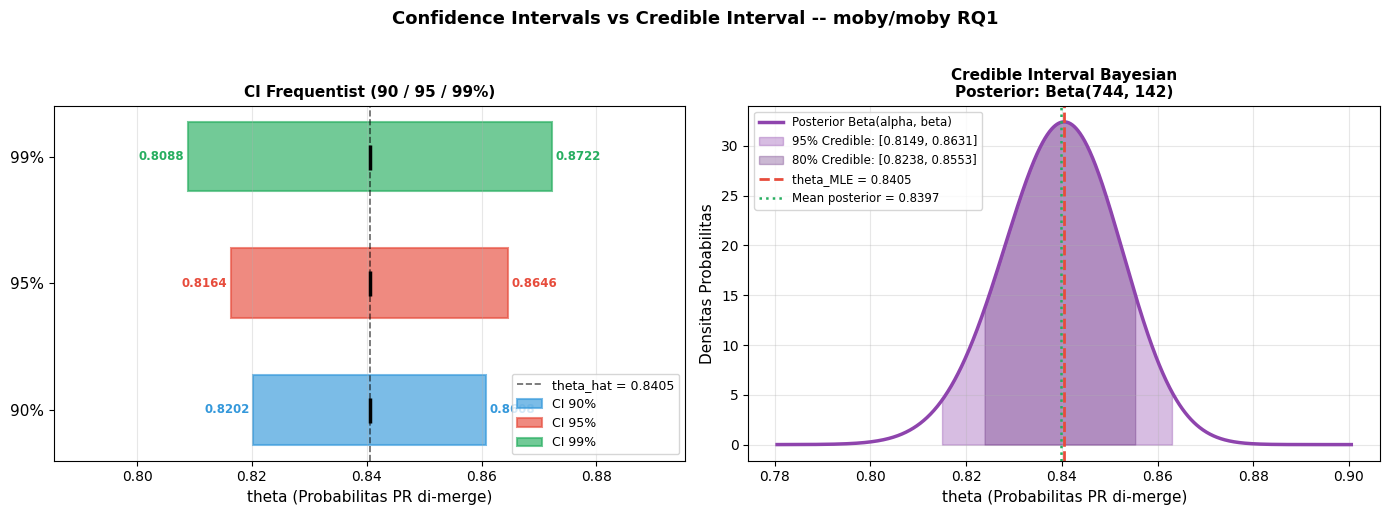

Plot tersimpan: data/clean/ci_comparison.png


In [5]:
# =============================================================================
#  VISUALISASI 1 -- CI Frequentist vs Credible Interval (moby/moby RQ1)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confidence Intervals vs Credible Interval -- moby/moby RQ1",
             fontsize=13, fontweight="bold", y=1.02)

# ---- Plot kiri: diagram batang horizontal CI Frequentist ----
cis_all  = [ci_90, ci_95, ci_99]
levels   = ["90%", "95%", "99%"]
palette  = ["#3498db", "#e74c3c", "#27ae60"]

for i, (ci, lv, col) in enumerate(zip(cis_all, levels, palette)):
    width_bar = ci["upper"] - ci["lower"]
    axes[0].barh(i, width_bar, left=ci["lower"],
                 color=col, alpha=0.65, height=0.55,
                 edgecolor=col, linewidth=1.5, label=f"CI {lv}")
    axes[0].plot(THETA_HAT, i, "k|", markersize=18, markeredgewidth=2.5, zorder=5)
    axes[0].text(ci["lower"] - 0.0006, i, f"{ci['lower']:.4f}",
                 ha="right", va="center", fontsize=8.5, color=col, fontweight="bold")
    axes[0].text(ci["upper"] + 0.0006, i, f"{ci['upper']:.4f}",
                 ha="left",  va="center", fontsize=8.5, color=col, fontweight="bold")

axes[0].set_yticks(range(3))
axes[0].set_yticklabels(levels, fontsize=11)
axes[0].set_xlabel("theta (Probabilitas PR di-merge)", fontsize=11)
axes[0].set_title("CI Frequentist (90 / 95 / 99%)", fontsize=11, fontweight="bold")
axes[0].axvline(THETA_HAT, color="black", linestyle="--", linewidth=1.2,
                alpha=0.6, label=f"theta_hat = {THETA_HAT:.4f}")
axes[0].legend(fontsize=9, loc="lower right")
axes[0].grid(alpha=0.3, axis="x")
axes[0].set_xlim(THETA_HAT - 0.055, THETA_HAT + 0.055)

# ---- Plot kanan: distribusi Beta posterior + shaded credible interval ----
t_min = max(0.001, THETA_HAT - 0.06)
t_max = min(0.999, THETA_HAT + 0.06)
x = np.linspace(t_min, t_max, 1000)
y = stats.beta.pdf(x, ALPHA_POST, BETA_POST)

axes[1].plot(x, y, color="#8e44ad", linewidth=2.5, label="Posterior Beta(alpha, beta)")

mask_95 = (x >= cred_95["lower"]) & (x <= cred_95["upper"])
axes[1].fill_between(x[mask_95], y[mask_95], alpha=0.35, color="#8e44ad",
                     label=f"95% Credible: [{cred_95['lower']:.4f}, {cred_95['upper']:.4f}]")
mask_80 = (x >= cred_80["lower"]) & (x <= cred_80["upper"])
axes[1].fill_between(x[mask_80], y[mask_80], alpha=0.35, color="#6c3483",
                     label=f"80% Credible: [{cred_80['lower']:.4f}, {cred_80['upper']:.4f}]")

axes[1].axvline(THETA_HAT, color="#e74c3c", linestyle="--", linewidth=2,
                label=f"theta_MLE = {THETA_HAT:.4f}")
axes[1].axvline(cred_95["mean"], color="#27ae60", linestyle=":",
                linewidth=1.8, label=f"Mean posterior = {cred_95['mean']:.4f}")
axes[1].set_xlabel("theta (Probabilitas PR di-merge)", fontsize=11)
axes[1].set_ylabel("Densitas Probabilitas", fontsize=11)
axes[1].set_title(f"Credible Interval Bayesian\nPosterior: Beta({ALPHA_POST}, {BETA_POST})",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8.5, loc="upper left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
os.makedirs("../data/clean", exist_ok=True)
plt.savefig("../data/clean/ci_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot tersimpan: data/clean/ci_comparison.png")

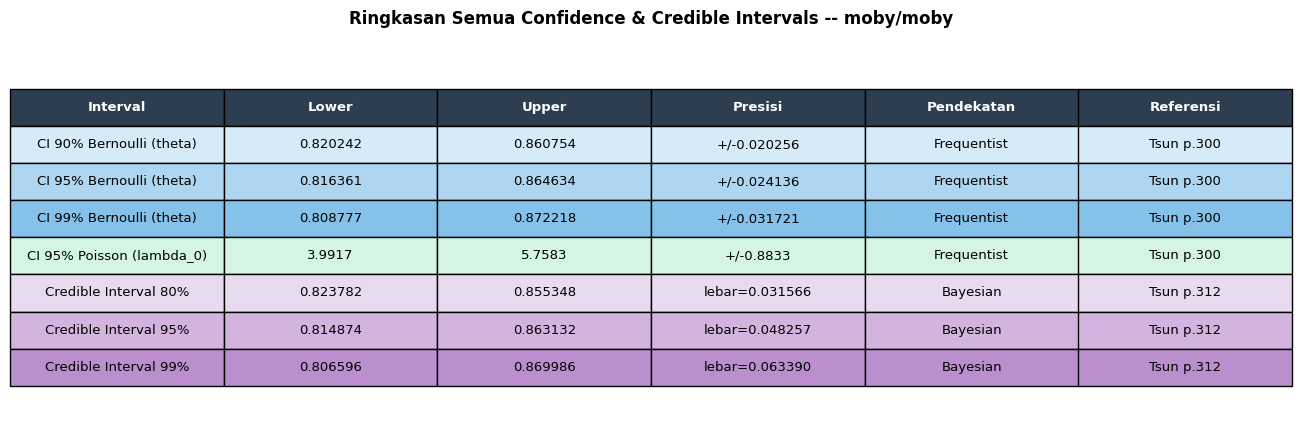

Tabel tersimpan: data/clean/ci_summary_table.png


In [6]:
# =============================================================================
#  VISUALISASI 2 -- Tabel Ringkasan Semua Interval
# =============================================================================

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.set_axis_off()

rows = [
    ["CI 90% Bernoulli (theta)",  f"{ci_90['lower']:.6f}", f"{ci_90['upper']:.6f}",
     f"+/-{ci_90['margin_of_error']:.6f}", "Frequentist", "Tsun p.300"],
    ["CI 95% Bernoulli (theta)",  f"{ci_95['lower']:.6f}", f"{ci_95['upper']:.6f}",
     f"+/-{ci_95['margin_of_error']:.6f}", "Frequentist", "Tsun p.300"],
    ["CI 99% Bernoulli (theta)",  f"{ci_99['lower']:.6f}", f"{ci_99['upper']:.6f}",
     f"+/-{ci_99['margin_of_error']:.6f}", "Frequentist", "Tsun p.300"],
    ["CI 95% Poisson (lambda_0)", f"{ci_pois_95['lower']:.4f}", f"{ci_pois_95['upper']:.4f}",
     f"+/-{ci_pois_95['margin_of_error']:.4f}", "Frequentist", "Tsun p.300"],
    ["Credible Interval 80%",     f"{cred_80['lower']:.6f}", f"{cred_80['upper']:.6f}",
     f"lebar={cred_80['width']:.6f}",  "Bayesian", "Tsun p.312"],
    ["Credible Interval 95%",     f"{cred_95['lower']:.6f}", f"{cred_95['upper']:.6f}",
     f"lebar={cred_95['width']:.6f}",  "Bayesian", "Tsun p.312"],
    ["Credible Interval 99%",     f"{cred_99['lower']:.6f}", f"{cred_99['upper']:.6f}",
     f"lebar={cred_99['width']:.6f}",  "Bayesian", "Tsun p.312"],
]

cols = ["Interval", "Lower", "Upper", "Presisi", "Pendekatan", "Referensi"]
row_colors = [
    ["#d6eaf8"] * 6, ["#aed6f1"] * 6, ["#85c1e9"] * 6, ["#d5f5e3"] * 6,
    ["#e8daef"] * 6, ["#d2b4de"] * 6, ["#bb8fce"] * 6,
]

table = ax.table(cellText=rows, colLabels=cols, cellLoc="center",
                 loc="center", cellColours=row_colors)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.2, 2.0)
for j in range(len(cols)):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

ax.set_title("Ringkasan Semua Confidence & Credible Intervals -- moby/moby",
             fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../data/clean/ci_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Tabel tersimpan: data/clean/ci_summary_table.png")

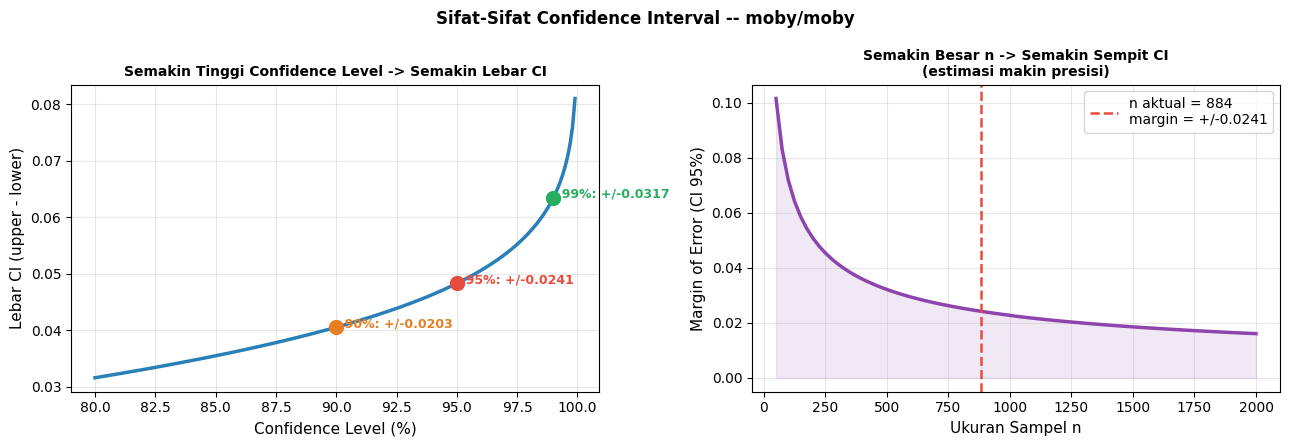

Plot tersimpan: data/clean/ci_properties.png


In [7]:
# =============================================================================
#  VISUALISASI 3 -- Sifat CI: Confidence Level vs Lebar & Efek n
# =============================================================================

confidence_levels = np.linspace(0.80, 0.999, 200)
widths = []
for conf in confidence_levels:
    ci_tmp = ci_bernoulli(K, N, confidence=conf)
    widths.append(ci_tmp["upper"] - ci_tmp["lower"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Sifat-Sifat Confidence Interval -- moby/moby",
             fontsize=12, fontweight="bold")

# ---- Lebar CI vs confidence level ----
axes[0].plot(confidence_levels * 100, widths, color="#2980b9", linewidth=2.5)
for conf, color, label in [(0.90,"#e67e22","90%"), (0.95,"#e74c3c","95%"), (0.99,"#27ae60","99%")]:
    ci_tmp = ci_bernoulli(K, N, confidence=conf)
    w = ci_tmp["upper"] - ci_tmp["lower"]
    axes[0].plot(conf * 100, w, "o", color=color, markersize=10, zorder=5)
    axes[0].annotate(f"  {label}: +/-{ci_tmp['margin_of_error']:.4f}",
                     xy=(conf*100, w), fontsize=9, color=color, fontweight="bold")
axes[0].set_xlabel("Confidence Level (%)", fontsize=11)
axes[0].set_ylabel("Lebar CI (upper - lower)", fontsize=11)
axes[0].set_title("Semakin Tinggi Confidence Level -> Semakin Lebar CI", fontsize=10, fontweight="bold")
axes[0].grid(alpha=0.3)

# ---- Efek ukuran sampel pada CI 95% ----
n_values = range(50, 2001, 25)
margins = []
for n_v in n_values:
    k_v = int(round(THETA_HAT * n_v))
    ci_v = ci_bernoulli(k_v, n_v, 0.95)
    margins.append(ci_v["margin_of_error"])

axes[1].plot(list(n_values), margins, color="#8e44ad", linewidth=2.5)
axes[1].axvline(N, color="#e74c3c", linestyle="--", linewidth=1.8,
                label=f"n aktual = {N}\nmargin = +/-{ci_95['margin_of_error']:.4f}")
axes[1].fill_between(list(n_values), margins, alpha=0.12, color="#8e44ad")
axes[1].set_xlabel("Ukuran Sampel n", fontsize=11)
axes[1].set_ylabel("Margin of Error (CI 95%)", fontsize=11)
axes[1].set_title("Semakin Besar n -> Semakin Sempit CI\n(estimasi makin presisi)", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/clean/ci_properties.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot tersimpan: data/clean/ci_properties.png")

## Summary & Handoff ke Member D (Hypothesis Analyst)

### Temuan Utama

| Interval | Lower | Upper | Tipe | Catatan |
|----------|-------|-------|------|---------|
| CI 90% theta Bernoulli | [isi] | [isi] | Frequentist | — |
| **CI 95% theta Bernoulli** | **[isi]** | **[isi]** | **Frequentist** | **Standar** |
| CI 99% theta Bernoulli | [isi] | [isi] | Frequentist | — |
| **CI 95% lambda Poisson** | **[isi]** | **[isi]** | **Frequentist** | **Digunakan sebagai mu_0** |
| Credible Interval 95% | [isi] | [isi] | Bayesian | Hampir sama dengan CI 95% |

*(Isi nilai dari output sel di atas setelah notebook dijalankan)*

### Nilai Kritis untuk Member D

```
mu_0 (H_0 pada RQ2) = lambda_hat baseline = [isi nilai dari ci_pois_95["lambda_hat"]]
```

CI Poisson yang **sempit** menunjukkan bahwa perubahan sekecil apapun pada laju bug  
akan terdeteksi "signifikan" secara statistik jika n cukup besar.  
Waspadai perbedaan antara **statistical significance** dan **practical significance** (relevan untuk RQ2).

### Catatan Teknis

- Semua perhitungan menggunakan **CLT (Central Limit Theorem)** -- valid karena n besar
- Formula CI Frequentist: `theta_hat +/- z_{1-alpha/2} * sigma/sqrt(n)` (Tsun 2020, p. 300)
- Formula Credible: kuantil dari `Beta(k+1, m+1)` (Tsun 2020, p. 312)
- **alpha = k+1**, **beta = m+1** -- WAJIB +1 (prior uniform Beta(1,1))

### Checklist Member C

- [ ] CI Bernoulli 95% & 99% dihitung via `ci_bernoulli()` dari `inference.py`
- [ ] CI Poisson 95% dihitung via `ci_poisson()` dari `inference.py`
- [ ] Credible Interval 80%, 95%, 99% dihitung via `credible_interval()` dari `inference.py`
- [ ] Interpretasi CI frequentist menggunakan wording yang tepat (prosedur berulang)
- [ ] Interpretasi credible interval menggunakan wording Bayesian yang tepat
- [ ] TIDAK ADA frasa "95% probabilitas theta ada di sini" untuk CI frequentist
- [ ] Visualisasi 1 (ci_comparison.png), 2 (ci_summary_table.png), 3 (ci_properties.png) tersimpan
- [ ] Nilai mu_0 diteruskan ke Member D dengan jelas